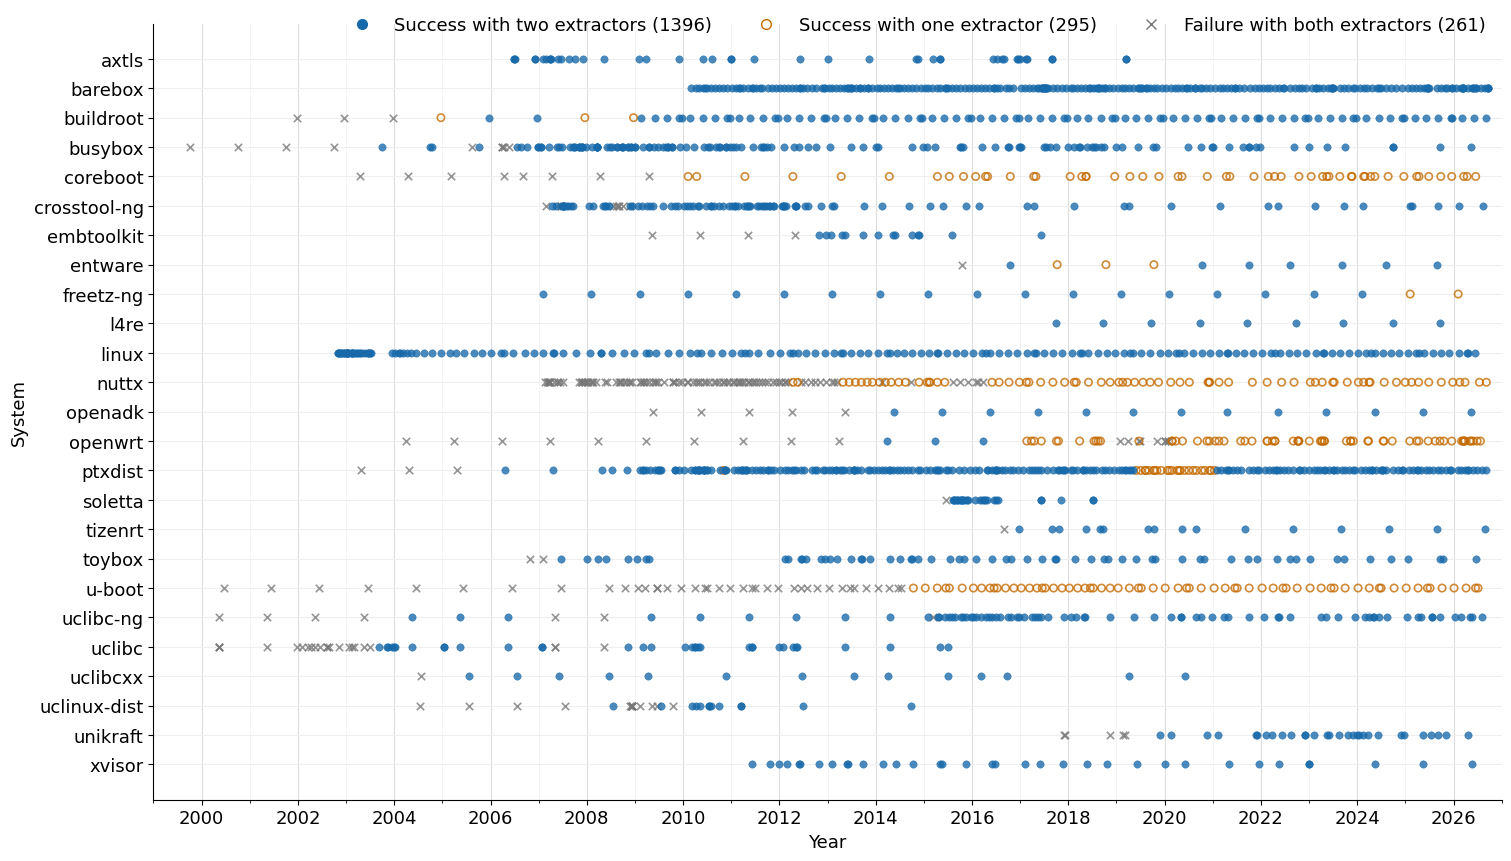

Wrote /Users/ek/git/dev-torte/experiments/feature-model-histories/extraction-history.svg with 1952 points.
States: 1396 both succeeded, 295 one failed, 261 both failed.


In [24]:
"""Plot extraction outcomes for the feature-model histories experiment."""

from __future__ import annotations

import csv
import datetime as dt
import re
import shlex
from collections import Counter
from pathlib import Path

try:
    from IPython import get_ipython
    from IPython.display import display as display_inline
except ImportError:
    get_ipython = None
    display_inline = None

if get_ipython is not None and get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def find_experiment_dir() -> Path:
    """Find this experiment directory from a script, notebook, or repo-root session."""
    candidates = []
    if "__file__" in globals() and not Path(__file__).name.startswith("<"):
        candidates.append(Path(__file__).resolve().parent)
    candidates.extend(
        [
            Path.cwd(),
            Path.cwd() / "experiments" / "feature-model-histories",
        ]
    )

    for candidate in candidates:
        if (candidate / "restrictions.csv").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate experiments/feature-model-histories.")


EXPERIMENT_DIR = find_experiment_dir()
REPO_ROOT = EXPERIMENT_DIR.parents[1]
INPUT_CSV = REPO_ROOT / "output.csv"
OUTPUT_PLOT = EXPERIMENT_DIR / "extraction-history.svg"

TITLE_SIZE = 15
LABEL_SIZE = 13
TICK_SIZE = 13
LEGEND_SIZE = 13
NOTE_SIZE = 8
MARKER_SIZE = 28
MARKER_LINE_WIDTH = 1.2
SUCCESS_MARKER_LINE_WIDTH = 0.4
LEGEND_MARKER_SIZE = 7

EXTRACTORS = {
    "extract-kconfig-models-with-kclause": "KClause",
    "extract-kconfig-models-with-kconfigreader": "KConfigReader",
}

STATE_ORDER = ["both_failed", "one_failed", "both_succeeded"]
STATE_LABELS = {
    "both_failed": "both failed",
    "one_failed": "one failed",
    "both_succeeded": "both succeeded",
}


def parse_date(row: dict[str, str]) -> dt.date:
    readable = row.get("committer_date_readable", "")
    if readable:
        return dt.date.fromisoformat(readable)
    return dt.datetime.fromtimestamp(int(row["committer_date_unix"]), tz=dt.UTC).date()


def succeeded(row: dict[str, str]) -> bool:
    model_file = row.get("model_file", "")
    return bool(row.get("model_features")) and bool(model_file) and not model_file.endswith("/NA")


def load_systems(experiment_file: Path, csv_path: Path) -> list[str]:
    csv_systems = []
    with csv_path.open(newline="") as handle:
        for row in csv.DictReader(handle):
            system = row["system"]
            if system not in csv_systems:
                csv_systems.append(system)

    experiment_systems = []
    match = re.search(r"SYSTEMS=\((.*?)\)", experiment_file.read_text(), re.DOTALL)
    if match:
        experiment_systems = shlex.split(match.group(1))

    ordered = [system for system in experiment_systems if system in csv_systems]
    ordered.extend(system for system in csv_systems if system not in ordered)
    return ordered


def load_points(csv_path: Path, systems: list[str]) -> list[dict[str, object]]:
    groups: dict[tuple[str, str, str, str, str], dict[str, object]] = {}

    with csv_path.open(newline="") as handle:
        for row in csv.DictReader(handle):
            extractor = row.get("extractor", "")
            if extractor not in EXTRACTORS:
                continue

            date = parse_date(row)
            key = (
                row["system"],
                row["revision"],
                row.get("context", ""),
                row.get("kconfig_file", ""),
                date.isoformat(),
            )
            point = groups.setdefault(
                key,
                {
                    "system": row["system"],
                    "revision": row["revision"],
                    "context": row.get("context", ""),
                    "kconfig_file": row.get("kconfig_file", ""),
                    "date": date,
                    "extractors": {},
                },
            )
            point["extractors"][extractor] = succeeded(row)  # type: ignore[index]

    system_order = {system: index for index, system in enumerate(systems)}
    points = []
    for point in groups.values():
        successes = sum(point["extractors"].values())  # type: ignore[union-attr]
        if successes == len(EXTRACTORS):
            state = "both_succeeded"
        elif successes == 1:
            state = "one_failed"
        else:
            state = "both_failed"
        point["state"] = state
        points.append(point)

    return sorted(points, key=lambda point: (system_order[str(point["system"])], point["date"]))  # type: ignore[arg-type]


def plot(points: list[dict[str, object]], output_path: Path, systems: list[str]) -> Counter:
    if not points:
        raise ValueError("No extraction rows found in the input CSV.")

    y_positions = {system: index for index, system in enumerate(systems)}
    fig_height = max(8.0, len(systems) * 0.34)
    fig, ax = plt.subplots(figsize=(15, fig_height), constrained_layout=True)

    styles = {
        "both_failed": {
            "marker": "x",
            "s": MARKER_SIZE,
            "linewidths": MARKER_LINE_WIDTH,
            "c": "#777777",
        },
        "one_failed": {
            "marker": "o",
            "s": MARKER_SIZE,
            "linewidths": MARKER_LINE_WIDTH,
            "facecolors": "none",
            "edgecolors": "#c46a00",
        },
        "both_succeeded": {
            "marker": "o",
            "s": MARKER_SIZE,
            "linewidths": SUCCESS_MARKER_LINE_WIDTH,
            "facecolors": "#1769aa",
            "edgecolors": "#1769aa",
        },
    }

    counts = Counter(str(point["state"]) for point in points)
    for state in STATE_ORDER:
        state_points = [point for point in points if point["state"] == state]
        ax.scatter(
            [point["date"] for point in state_points],
            [y_positions[str(point["system"])] for point in state_points],
            alpha=0.78,
            label=f"{STATE_LABELS[state]} ({counts[state]})",
            **styles[state],
        )

    ax.set_xlabel("Year", fontsize=LABEL_SIZE)
    ax.set_ylabel("System", fontsize=LABEL_SIZE)
    ax.set_yticks(range(len(systems)))
    ax.set_yticklabels(systems, fontsize=TICK_SIZE)
    ax.invert_yaxis()

    min_date = min(point["date"] for point in points)  # type: ignore[arg-type]
    max_date = max(point["date"] for point in points)  # type: ignore[arg-type]
    ax.set_xlim(dt.date(min_date.year, 1, 1), dt.date(max_date.year + 1, 1, 1))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))
    ax.tick_params(axis="x", labelsize=TICK_SIZE)

    ax.grid(axis="x", which="major", color="#dddddd", linewidth=0.8)
    ax.grid(axis="x", which="minor", color="#eeeeee", linewidth=0.5)
    ax.grid(axis="y", color="#eeeeee", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_handles = [
        Line2D([0], [0], marker="o", color="#1769aa", markerfacecolor="#1769aa", linestyle="None", markersize=LEGEND_MARKER_SIZE, label=f"Success with two extractors ({counts['both_succeeded']})"),
        Line2D([0], [0], marker="o", color="#c46a00", markerfacecolor="none", linestyle="None", markersize=LEGEND_MARKER_SIZE, label=f"Success with one extractor ({counts['one_failed']})"),
        Line2D([0], [0], marker="x", color="#777777", linestyle="None", markersize=LEGEND_MARKER_SIZE, label=f"Failure with both extractors ({counts['both_failed']})"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=False, ncol=3, bbox_to_anchor=(1, 1.03), fontsize=LEGEND_SIZE)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300)
    if display_inline is not None:
        display_inline(fig)
    plt.close(fig)
    return counts


systems = load_systems(EXPERIMENT_DIR / "experiment.sh", INPUT_CSV)
points = load_points(INPUT_CSV, systems)
counts = plot(points, OUTPUT_PLOT, systems)
print(f"Wrote {OUTPUT_PLOT} with {len(points)} points.")
print(
    "States: "
    f"{counts['both_succeeded']} both succeeded, "
    f"{counts['one_failed']} one failed, "
    f"{counts['both_failed']} both failed."
)
